
# Volatility Index & Implied Volatility Time Series

This notebook constructs:

1. A **volatility index** from SPX option implied volatilities.
2. **Time series of implied volatility** for a few key strikes:
   - At-the-money (ATM) option  
   - Out-of-the-money (OTM) put  
   - Out-of-the-money (OTM) call  

You can adapt the file paths and parameters in the configuration cell to match your data.


In [43]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

# Display options
pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", 20)


## 1. Configuration

In [ ]:
# Path to SPX / ES / VIX time series
assets_path = "RTH/2025-04-01_assets.csv"  # example

# List of option expiries and corresponding bid/ask files
# Add more dicts if you have multiple expiries.
option_files = [
    {
        "expiry": "2025-04-16",
        "call_bid": "RTH/2025-04-01_call_bid_20250416.csv",
        "call_ask": "RTH/2025-04-01_call_ask_20250416.csv",
        # If you have puts, include them as well; otherwise leave as None.
        "put_bid": "RTH/2025-04-01_put_bid_20250416.csv",
        "put_ask": "RTH/2025-04-01_put_ask_20250416.csv",
    },
]

# Risk-free rate and dividend yield (annualized)
r = 0.02  # example 2% risk-free rate
q = 0.0   # assume 0 dividend yield unless you have better data

# Target maturity (for volatility index & key-strike time series), in calendar days
target_maturity_days = 14.5

# Event date (for plotting / reference only)
event_date = pd.to_datetime("2025-04-02")  # replace with actual event date if needed


## 2. Load and reshape data

In [45]:

def load_assets(path):
    """Load SPX / ES / VIX time series."""
    df = pd.read_csv(path, parse_dates=[0])
    df.rename(columns={'Unnamed: 0': 'timestamp'}, inplace=True)
    df = df.sort_values("timestamp")
    return df

def melt_option_wide(df, value_name):
    """
    Convert wide option data (timestamp + strike columns) into long format.

    Expected format:
        timestamp | 4000 | 4050 | 4100 | ...
    """
    strike_cols = [c for c in df.columns if c != "timestamp"]
    long_df = df.melt(
        id_vars="timestamp",
        value_vars=strike_cols,
        var_name="strike",
        value_name=value_name,
    )
    long_df["strike"] = long_df["strike"].astype(float)
    return long_df


def load_options_for_expiry(cfg):
    """
    Given a config dict with expiry and file paths, return a long-format options DataFrame:

    columns: timestamp, expiry, option_type, strike, bid, ask, mid
    """
    expiry = pd.to_datetime(cfg["expiry"])

    all_parts = []

    # Calls
    if cfg.get("call_bid") is not None and cfg.get("call_ask") is not None:
        call_bid = pd.read_csv(cfg["call_bid"], parse_dates=[0])
        call_bid.rename(columns={'Unnamed: 0': 'timestamp'}, inplace=True)
        call_ask = pd.read_csv(cfg["call_ask"], parse_dates=[0])
        call_ask.rename(columns={'Unnamed: 0': 'timestamp'}, inplace=True)


        call_bid_long = melt_option_wide(call_bid, "bid")
        call_ask_long = melt_option_wide(call_ask, "ask")

        calls = call_bid_long.merge(
            call_ask_long, on=["timestamp", "strike"], how="outer"
        )
        calls["option_type"] = "C"
        calls["expiry"] = expiry
        all_parts.append(calls)

    # Puts (if provided)
    if cfg.get("put_bid") is not None and cfg.get("put_ask") is not None:
        put_bid = pd.read_csv(cfg["put_bid"], parse_dates=[0])
        put_bid.rename(columns={'Unnamed: 0': 'timestamp'}, inplace=True)
        put_ask = pd.read_csv(cfg["put_ask"], parse_dates=[0])
        put_ask.rename(columns={'Unnamed: 0': 'timestamp'}, inplace=True)

        put_bid_long = melt_option_wide(put_bid, "bid")
        put_ask_long = melt_option_wide(put_ask, "ask")

        puts = put_bid_long.merge(
            put_ask_long, on=["timestamp", "strike"], how="outer"
        )
        puts["option_type"] = "P"
        puts["expiry"] = expiry
        all_parts.append(puts)

    if not all_parts:
        return pd.DataFrame(columns=["timestamp", "expiry", "option_type", "strike", "bid", "ask", "mid"])

    df = pd.concat(all_parts, ignore_index=True)

    # Mid-price
    df["mid"] = 0.5 * (df["bid"] + df["ask"])

    return df


# --- Load everything ---
assets = load_assets(assets_path)

option_frames = []
for cfg in option_files:
    option_frames.append(load_options_for_expiry(cfg))

options = pd.concat(option_frames, ignore_index=True)
options = options.dropna(subset=["mid"])
options = options.sort_values(["timestamp", "expiry", "strike"])

# Merge SPX into options
data = options.merge(
    assets[["timestamp", "SPX"]], on="timestamp", how="left"
)
data = data.dropna(subset=["SPX"])

# Time to maturity in years
data["T"] = (
    data["expiry"] - data["timestamp"]
).dt.total_seconds() / (365.0 * 24 * 3600)

data.head()


,timestamp,strike,bid,ask,option_type,expiry,mid,SPX,T
0,2025-04-01 09:31:21.491248,4600.0,995.2,1006.3,C,2025-04-16,1000.75,5590.32,0.040009
1,2025-04-01 09:31:21.491248,4600.0,3.2,3.5,P,2025-04-16,3.35,5590.32,0.040009
2,2025-04-01 09:31:21.491248,4625.0,971.7,981.5,C,2025-04-16,976.60,5590.32,0.040009
3,2025-04-01 09:31:21.491248,4625.0,3.3,3.6,P,2025-04-16,3.45,5590.32,0.040009
4,2025-04-01 09:31:21.491248,4650.0,945.7,956.7,C,2025-04-16,951.20,5590.32,0.040009


## 3. Black–Scholes and implied volatility

In [46]:

def bs_price(S, K, T, r, sigma, option_type="C", q=0.0):
    """Black–Scholes price for a European call or put."""
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        intrinsic = max(0.0, (S - K) if option_type == "C" else (K - S))
        return intrinsic

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "C":
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)


def implied_vol(price, S, K, T, r, option_type="C", q=0.0, sigma_bounds=(1e-4, 5.0)):
    """
    Solve for implied volatility using a 1D root-finder.

    Returns NaN if no valid solution is found.
    """
    if price is None or np.isnan(price):
        return np.nan
    if price <= 0 or S <= 0 or K <= 0 or T <= 0:
        return np.nan

    intrinsic = max(0.0, (S - K) if option_type == "C" else (K - S))
    if price < intrinsic:
        # Observed price below intrinsic value is inconsistent
        return np.nan

    def f(sigma):
        return bs_price(S, K, T, r, sigma, option_type, q) - price

    lo, hi = sigma_bounds
    try:
        return brentq(f, lo, hi)
    except Exception:
        return np.nan


# Apply IV computation row-wise
def compute_iv_for_row(row):
    return implied_vol(
        price=row["mid"],
        S=row["SPX"],
        K=row["strike"],
        T=row["T"],
        r=r,
        option_type=row["option_type"],
        q=q,
    )


# This may take a bit of time depending on dataset size
data["iv"] = data.apply(compute_iv_for_row, axis=1)
data.head()


,timestamp,strike,bid,ask,option_type,expiry,mid,SPX,T,iv
0,2025-04-01 09:31:21.491248,4600.0,995.2,1006.3,C,2025-04-16,1000.75,5590.32,0.040009,0.529246
1,2025-04-01 09:31:21.491248,4600.0,3.2,3.5,P,2025-04-16,3.35,5590.32,0.040009,0.472536
2,2025-04-01 09:31:21.491248,4625.0,971.7,981.5,C,2025-04-16,976.60,5590.32,0.040009,0.527660
3,2025-04-01 09:31:21.491248,4625.0,3.3,3.6,P,2025-04-16,3.45,5590.32,0.040009,0.463262
4,2025-04-01 09:31:21.491248,4650.0,945.7,956.7,C,2025-04-16,951.20,5590.32,0.040009,0.509865


In [56]:
# data.to_csv("IV_Calc/2024-04-01_RTH_iv")
sample = data[data["timestamp"] == data["timestamp"].iloc[5000]].copy()
sample["moneyness"] = sample["strike"] / sample["SPX"]
sample = sample[(sample["T"]*365).between(12, 17)]

print("ATM strike:", sample["SPX"].iloc[0])
print(sample.groupby(pd.cut(sample["moneyness"], bins=[0.5, 0.8, 0.95, 1.05, 1.2, 1.4]))["iv"].mean())


ATM strike: 5593.97
moneyness
(0.5, 0.8]           NaN
(0.8, 0.95]     0.385269
(0.95, 1.05]    0.220570
(1.05, 1.2]     0.183116
(1.2, 1.4]           NaN
Name: iv, dtype: float64


/var/folders/zd/bw31n1px0zs48_3fkr0f7skr0000gn/T/ipykernel_29240/2092481951.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sample.groupby(pd.cut(sample["moneyness"], bins=[0.5, 0.8, 0.95, 1.05, 1.2, 1.4]))["iv"].mean())


## 4. Construct a volatility index

In [67]:

def build_vol_index(df, target_days=30, moneyness_band=0.2, maturity_window=2.0):
    """
    Build a simple volatility index time series.

    Steps:
    1. For each timestamp, pick options near the target maturity (e.g., 30 days).
    2. Restrict to strikes with moneyness in [1 - band, 1 + band].
    3. Compute mean of squared implied vols and convert it to 30-day volatility.
    """
    records = []

    for t, group in df.groupby("timestamp"):
        g = group.copy()
        if g.empty:
            continue

        # T in days
        g["T_days"] = g["T"] * 365.0
        # Choose maturity closest to target_days
        idx = (g["T_days"] - target_days).abs().idxmin()
        T_star = g.loc[idx, "T_days"]
        # Narrow to a small window around that maturity
        g = g[g["T_days"].between(T_star - maturity_window, T_star + maturity_window)]
        if g.empty:
            continue

        # Moneyness filter
        g["moneyness"] = g["strike"] / g["SPX"]
        band_low = 1.0 - moneyness_band
        band_high = 1.0 + moneyness_band
        g = g[(g["moneyness"] >= band_low) & (g["moneyness"] <= band_high)]

        sigmas = g["iv"].dropna().values
        if len(sigmas) == 0:
            continue

        # sigma2 = np.mean(sigmas**2)  # annualized variance
        # vol_30d = np.sqrt(abs(sigma2) * (target_days / 365.0))
        
        # TODO: ATTEMPTED FIX 1:
        sigma2 = np.mean(sigmas**2)
        vol_index = np.median(sigmas)

        records.append(
            {
                "timestamp": t,
                "vol_index": vol_index,
            }
        )

    out = pd.DataFrame(records).sort_values("timestamp")
    return out


vol_index_df = build_vol_index(
    data,
    target_days=target_maturity_days,
    moneyness_band=0.05,
    maturity_window=2.0,
)

vol_index_df.head()


,timestamp,vol_index
0,2025-04-01 09:31:21.491248,0.223236
1,2025-04-01 09:31:24.535800,0.223487
2,2025-04-01 09:31:27.582698,0.221640
3,2025-04-01 09:31:30.632772,0.222782
4,2025-04-01 09:31:33.638817,0.223965


### 4.1 Compare with VIX

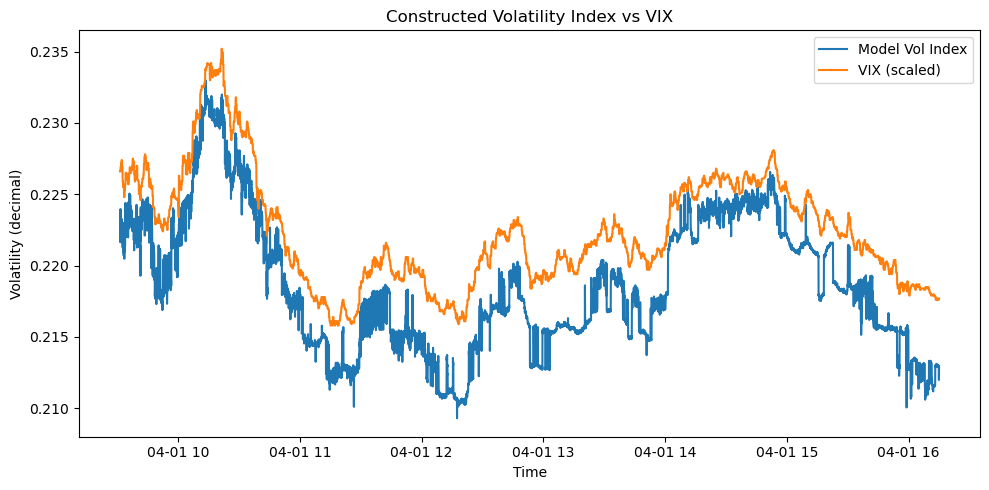

In [72]:

vol_ts = vol_index_df.merge(
    assets[["timestamp", "VIX"]],
    on="timestamp",
    how="left",
)

plt.figure(figsize=(10, 5))
plt.plot(vol_ts["timestamp"], vol_ts["vol_index"], label="Model Vol Index")
# VIX is usually in percent; divide by 100 to convert to decimal volatility
plt.plot(vol_ts["timestamp"], vol_ts["VIX"] / 100.0, label="VIX (scaled)")
# plt.axvline(event_date, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Volatility (decimal)")
plt.title("Constructed Volatility Index vs VIX")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Time series of implied volatility at key strikes

In [69]:

def pick_key_strikes(group, atm_offset=200.0):
    """
    Given a group of options at one timestamp, pick ATM, OTM call, OTM put.
    """
    g = group.copy()
    S = g["SPX"].iloc[0]
    strikes = np.sort(g["strike"].unique())

    def nearest(k):
        idx = np.argmin(np.abs(strikes - k))
        return float(strikes[idx])

    atm_strike = nearest(S)
    k_call = nearest(S + atm_offset)
    k_put = nearest(S - atm_offset)
    return atm_strike, k_call, k_put


def build_key_iv_timeseries(df, target_days=30, maturity_window=2.0, atm_offset=200.0):
    records = []

    for t, group in df.groupby("timestamp"):
        g = group.copy()
        if g.empty:
            continue

        # maturity filter
        g["T_days"] = g["T"] * 365.0
        idx = (g["T_days"] - target_days).abs().idxmin()
        T_star = g.loc[idx, "T_days"]
        g = g[g["T_days"].between(T_star - maturity_window, T_star + maturity_window)]
        if g.empty:
            continue

        atm_strike, k_call, k_put = pick_key_strikes(g, atm_offset=atm_offset)

        iv_atm = g.loc[g["strike"] == atm_strike, "iv"].mean()
        iv_otm_call = g.loc[
            (g["strike"] == k_call) & (g["option_type"] == "C"),
            "iv",
        ].mean()
        iv_otm_put = g.loc[
            (g["strike"] == k_put) & (g["option_type"] == "P"),
            "iv",
        ].mean()

        records.append(
            {
                "timestamp": t,
                "iv_atm": iv_atm,
                "iv_otm_call": iv_otm_call,
                "iv_otm_put": iv_otm_put,
            }
        )

    out = pd.DataFrame(records).sort_values("timestamp")
    return out


iv_keys_df = build_key_iv_timeseries(
    data,
    target_days=target_maturity_days,
    maturity_window=2.0,
    atm_offset=200.0,
)

iv_keys_df.head()


,timestamp,iv_atm,iv_otm_call,iv_otm_put
0,2025-04-01 09:31:21.491248,0.218711,0.182680,0.249825
1,2025-04-01 09:31:24.535800,0.218487,0.182633,0.250083
2,2025-04-01 09:31:27.582698,0.218934,0.182353,0.251016
3,2025-04-01 09:31:30.632772,0.219044,0.182590,0.250452
4,2025-04-01 09:31:33.638817,0.218877,0.182856,0.250707


### 5.1 Plot key-strike IVs and SPX

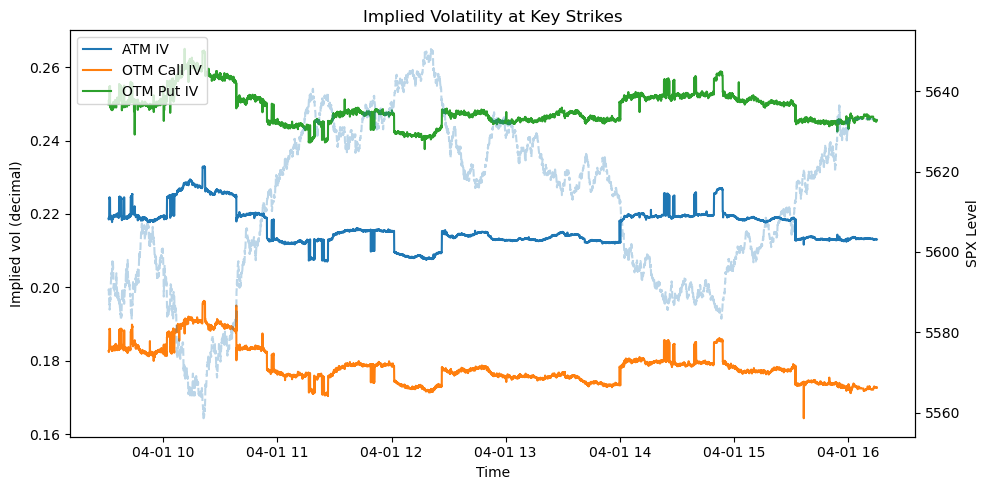

In [71]:

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(iv_keys_df["timestamp"], iv_keys_df["iv_atm"], label="ATM IV")
ax1.plot(iv_keys_df["timestamp"], iv_keys_df["iv_otm_call"], label="OTM Call IV")
ax1.plot(iv_keys_df["timestamp"], iv_keys_df["iv_otm_put"], label="OTM Put IV")
ax1.set_xlabel("Time")
ax1.set_ylabel("Implied vol (decimal)")
# ax1.axvline(event_date, linestyle="--")
ax1.legend(loc="upper left")
ax1.set_title("Implied Volatility at Key Strikes")

# Overlay SPX on a secondary axis
ax2 = ax1.twinx()
ax2.plot(assets["timestamp"], assets["SPX"], linestyle="--", alpha=0.3)
ax2.set_ylabel("SPX Level")

fig.tight_layout()
plt.show()



## 6. How to analyze the results

When you run the notebook, focus on these patterns:

1. **Volatility index vs VIX**
   - Does your constructed index spike around the event date similar to VIX?
   - Is it smoother or more volatile than VIX?
   - How quickly does it mean-revert after the event?

2. **Key-strike implied volatilities**
   - Check whether **OTM put IV** is higher than ATM and OTM call IV (equity skew).
   - During the event, does the OTM put IV spike disproportionately (crash protection becoming expensive)?
   - After the event, do the three series converge back toward their pre-event levels?

3. **Relation to SPX**
   - Overlay SPX level movements with your IV series (as in the last plot).
   - Large SPX drops on the event day should correspond to spikes in IV (especially puts).
